In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
df=pd.read_csv("C:/Users/Adhrav/Desktop/Env/notebooks/data/loan_processed.csv")
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanIncomeRatio,TotalIncome_Log,LoanAmount_Log
0,Male,No,0.0,Graduate,No,360.0,1.0,Urban,Y,0.021884,8.674197,4.859812
1,Male,Yes,1.0,Graduate,No,360.0,1.0,Rural,N,0.021015,8.714732,4.859812
2,Male,Yes,0.0,Graduate,Yes,360.0,1.0,Urban,Y,0.022000,8.006701,4.204693
3,Male,Yes,0.0,Not Graduate,No,360.0,1.0,Urban,Y,0.024287,8.505525,4.795791
4,Male,No,0.0,Graduate,No,360.0,1.0,Urban,Y,0.023500,8.699681,4.955827


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            614 non-null    object 
 1   Married           614 non-null    object 
 2   Dependents        614 non-null    float64
 3   Education         614 non-null    object 
 4   Self_Employed     614 non-null    object 
 5   Loan_Amount_Term  614 non-null    float64
 6   Credit_History    614 non-null    float64
 7   Property_Area     614 non-null    object 
 8   Loan_Status       614 non-null    object 
 9   LoanIncomeRatio   614 non-null    float64
 10  TotalIncome_Log   614 non-null    float64
 11  LoanAmount_Log    614 non-null    float64
dtypes: float64(6), object(6)
memory usage: 57.7+ KB


In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder


In [70]:
df['Self_Employed'].value_counts()

Self_Employed
No     532
Yes     82
Name: count, dtype: int64

In [71]:
df['Gender']=df['Gender'].map({'Male':0,'Female':1})

df['Married']=df['Married'].map({'Yes':0,'No':1})

df['Education']=df['Education'].map({'Graduate':0,'Not Graduate':1})

df['Self_Employed']=df['Self_Employed'].map({'Yes':0,'No':1})




In [72]:
df['Loan_Status']=df['Loan_Status'].map({'Y':0,'N':1})

In [73]:
df['Education']

0      0
1      0
2      0
3      1
4      0
      ..
609    0
610    0
611    0
612    0
613    0
Name: Education, Length: 614, dtype: int64

In [74]:
df

,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanIncomeRatio,TotalIncome_Log,LoanAmount_Log
0,0,1,0.0,0,1,360.0,1.0,Urban,0,0.021884,8.674197,4.859812
1,0,0,1.0,0,1,360.0,1.0,Rural,1,0.021015,8.714732,4.859812
2,0,0,0.0,0,0,360.0,1.0,Urban,0,0.022000,8.006701,4.204693
3,0,0,0.0,1,1,360.0,1.0,Urban,0,0.024287,8.505525,4.795791
4,0,1,0.0,0,1,360.0,1.0,Urban,0,0.023500,8.699681,4.955827
...,...,...,...,...,...,...,...,...,...,...,...,...
609,1,1,0.0,0,1,360.0,1.0,Rural,0,0.024483,7.972811,4.276666
610,0,0,3.0,0,1,180.0,1.0,Rural,0,0.009742,8.320448,3.713572
611,0,0,1.0,0,1,360.0,1.0,Urban,0,0.030438,9.025576,5.537334
612,0,0,2.0,0,1,360.0,1.0,Urban,0,0.024660,8.933796,5.236442


In [75]:
df['Property_Area'].value_counts()

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

In [76]:
X=df.drop(columns=['Loan_Status'],axis=1)
X

,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,Property_Area,LoanIncomeRatio,TotalIncome_Log,LoanAmount_Log
0,0,1,0.0,0,1,360.0,1.0,Urban,0.021884,8.674197,4.859812
1,0,0,1.0,0,1,360.0,1.0,Rural,0.021015,8.714732,4.859812
2,0,0,0.0,0,0,360.0,1.0,Urban,0.022000,8.006701,4.204693
3,0,0,0.0,1,1,360.0,1.0,Urban,0.024287,8.505525,4.795791
4,0,1,0.0,0,1,360.0,1.0,Urban,0.023500,8.699681,4.955827
...,...,...,...,...,...,...,...,...,...,...,...
609,1,1,0.0,0,1,360.0,1.0,Rural,0.024483,7.972811,4.276666
610,0,0,3.0,0,1,180.0,1.0,Rural,0.009742,8.320448,3.713572
611,0,0,1.0,0,1,360.0,1.0,Urban,0.030438,9.025576,5.537334
612,0,0,2.0,0,1,360.0,1.0,Urban,0.024660,8.933796,5.236442


In [77]:
y=df['Loan_Status']
y

0      0
1      1
2      0
3      0
4      0
      ..
609    0
610    0
611    0
612    0
613    1
Name: Loan_Status, Length: 614, dtype: int64

In [78]:
X = pd.get_dummies(X, columns=['Property_Area'], drop_first=True)
X


,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,LoanIncomeRatio,TotalIncome_Log,LoanAmount_Log,Property_Area_Semiurban,Property_Area_Urban
0,0,1,0.0,0,1,360.0,1.0,0.021884,8.674197,4.859812,False,True
1,0,0,1.0,0,1,360.0,1.0,0.021015,8.714732,4.859812,False,False
2,0,0,0.0,0,0,360.0,1.0,0.022000,8.006701,4.204693,False,True
3,0,0,0.0,1,1,360.0,1.0,0.024287,8.505525,4.795791,False,True
4,0,1,0.0,0,1,360.0,1.0,0.023500,8.699681,4.955827,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
609,1,1,0.0,0,1,360.0,1.0,0.024483,7.972811,4.276666,False,False
610,0,0,3.0,0,1,180.0,1.0,0.009742,8.320448,3.713572,False,False
611,0,0,1.0,0,1,360.0,1.0,0.030438,9.025576,5.537334,False,True
612,0,0,2.0,0,1,360.0,1.0,0.024660,8.933796,5.236442,False,True


In [79]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   614 non-null    int64  
 1   Married                  614 non-null    int64  
 2   Dependents               614 non-null    float64
 3   Education                614 non-null    int64  
 4   Self_Employed            614 non-null    int64  
 5   Loan_Amount_Term         614 non-null    float64
 6   Credit_History           614 non-null    float64
 7   LoanIncomeRatio          614 non-null    float64
 8   TotalIncome_Log          614 non-null    float64
 9   LoanAmount_Log           614 non-null    float64
 10  Property_Area_Semiurban  614 non-null    bool   
 11  Property_Area_Urban      614 non-null    bool   
dtypes: bool(2), float64(6), int64(4)
memory usage: 49.3 KB


In [80]:
from sklearn.model_selection import train_test_split

X_test,X_train,y_test,y_train=train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [81]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [82]:
df['Loan_Status'].value_counts(normalize=True) * 100 #checking imbalance

Loan_Status
0    68.729642
1    31.270358
Name: proportion, dtype: float64

In [83]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression( max_iter=1000,class_weight='balanced')

lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [84]:
y_pred=lr.predict(X_test)

In [85]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy : ",accuracy_score(y_test,y_pred))
print("classification_report : ",classification_report(y_test,y_pred))
print("confusion_matrix: ",confusion_matrix(y_test,y_pred))

Accuracy :  0.7413441955193483
classification_report :                precision    recall  f1-score   support

           0       0.79      0.84      0.82       337
           1       0.60      0.52      0.56       154

    accuracy                           0.74       491
   macro avg       0.70      0.68      0.69       491
weighted avg       0.73      0.74      0.74       491

confusion_matrix:  [[284  53]
 [ 74  80]]


In [86]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [87]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy : ",accuracy_score(y_test,y_pred_dt))
print("classification_report : ",classification_report(y_test,y_pred_dt))
print("confusion_matrix: ",confusion_matrix(y_test,y_pred_dt))

Accuracy :  0.7556008146639511
classification_report :                precision    recall  f1-score   support

           0       0.82      0.83      0.82       337
           1       0.61      0.59      0.60       154

    accuracy                           0.76       491
   macro avg       0.72      0.71      0.71       491
weighted avg       0.75      0.76      0.75       491

confusion_matrix:  [[280  57]
 [ 63  91]]


In [88]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)


''' rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)'''

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [89]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy : ",accuracy_score(y_test,y_pred_rf))
print("classification_report : ",classification_report(y_test,y_pred_rf))
print("confusion_matrix: ",confusion_matrix(y_test,y_pred_rf))

Accuracy :  0.8004073319755601
classification_report :                precision    recall  f1-score   support

           0       0.79      0.96      0.87       337
           1       0.83      0.45      0.59       154

    accuracy                           0.80       491
   macro avg       0.81      0.71      0.73       491
weighted avg       0.81      0.80      0.78       491

confusion_matrix:  [[323  14]
 [ 84  70]]


### Random Forest:reduced false positives and improved acc

TotalIncome_Log            0.205436
LoanIncomeRatio            0.182387
Credit_History             0.172049
LoanAmount_Log             0.166168
Dependents                 0.067517
Property_Area_Semiurban    0.045539
Loan_Amount_Term           0.034801
Married                    0.030736
Property_Area_Urban        0.029155
Education                  0.024393
Self_Employed              0.024043
Gender                     0.017776
dtype: float64


<Axes: >

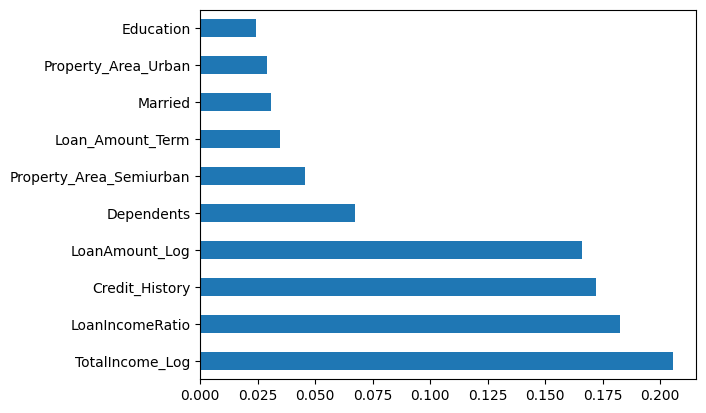

In [90]:
#checking imrotance of every features
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)
importance.head(10).plot(kind='barh')

In [91]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

0.7237562141122973

In [92]:
from sklearn.metrics import roc_auc_score

y_prob = lr.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

# lr has better roc auc 

0.7355004046398705

In [93]:
from sklearn.metrics import roc_auc_score

y_prob = dt.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

0.71088481251686

In [94]:
X

,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,LoanIncomeRatio,TotalIncome_Log,LoanAmount_Log,Property_Area_Semiurban,Property_Area_Urban
0,0,1,0.0,0,1,360.0,1.0,0.021884,8.674197,4.859812,False,True
1,0,0,1.0,0,1,360.0,1.0,0.021015,8.714732,4.859812,False,False
2,0,0,0.0,0,0,360.0,1.0,0.022000,8.006701,4.204693,False,True
3,0,0,0.0,1,1,360.0,1.0,0.024287,8.505525,4.795791,False,True
4,0,1,0.0,0,1,360.0,1.0,0.023500,8.699681,4.955827,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
609,1,1,0.0,0,1,360.0,1.0,0.024483,7.972811,4.276666,False,False
610,0,0,3.0,0,1,180.0,1.0,0.009742,8.320448,3.713572,False,False
611,0,0,1.0,0,1,360.0,1.0,0.030438,9.025576,5.537334,False,True
612,0,0,2.0,0,1,360.0,1.0,0.024660,8.933796,5.236442,False,True


In [95]:
# sinc lr has better roc auc so doing some CV
from sklearn.model_selection import cross_val_score

score=cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print(score)
print(score.mean())

[0.79721362 0.72786378 0.75396825 0.82142857 0.69235589]
0.7585660229003882


In [96]:
# HyperPara tuning
from sklearn.model_selection import GridSearchCV

params={
    'C':[0.01,0.1,1,10],
    'solver':['liblinear'],
    'class_weight':['balanced']
}


#grid searchCV
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    params,
    cv=5,
    scoring='roc_auc'
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 1, 'class_weight': 'balanced', 'solver': 'liblinear'}
0.705672268907563
